# Physics-loss ablation (simulated data)

Compare two training regimes on the **same** synthetic FROG setup:

| Run | Loss |
|-----|------|
| **A** | Supervised only: L1(`E_pred`, `E_true`) |
| **B** | Supervised + physics: L1(`E_pred`, `E_true`) + λ·L1(`FROGNet(E_pred)`, `I_noisy`) |

Both runs use **noisy traces in training** (SNR uniform in 0–30 dB). λ is chosen on **validation at 10 dB** by minimizing mean **δE**. Final comparison: **δE vs. trace SNR** on the test set (−10…30 dB).

Imports and project modules.

In [57]:
from __future__ import annotations

from pathlib import Path
from typing import Callable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from data_generation import generate_pulses_gaussian
from frognet import FROGNet
from frog_reconstruction_model import TraceToPulseCNN
from trace_noise import add_trace_noise_awgn

add_trace_noise: Callable[[torch.Tensor, float], torch.Tensor] = add_trace_noise_awgn

Hyperparameters (aligned with `reconstruction_snr_experiments.ipynb` where noted).

In [58]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0
MODEL_INIT_SEED = 42  # same initial weights for runs A and B

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

N = 64
N_TRAIN = 2048
N_VAL = 512
N_TEST = 512
BATCH_SIZE = 64
EPOCHS = 15
LAMBDA_SEARCH_EPOCHS = 8
LR = 1e-3

TRAIN_SNR_DB_RANGE = (0.0, 30.0)
LAMBDA_VAL_SNR_DB = 10.0  # SNR for λ selection on validation
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

LAMBDA_CANDIDATES = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0], dtype=np.float64)

CKPT_DIR = Path("checkpoints/physics_loss_ablation")
CKPT_A = CKPT_DIR / "run_a_supervised_only.pt"
CKPT_B = CKPT_DIR / "run_b_supervised_plus_physics.pt"

print("DEVICE:", DEVICE)

DEVICE: cpu


Build datasets: Gaussian pulses → `FROGNet` → clean traces; noise is added in the training/eval loops.

In [59]:
def pack_pulses_complex(pulses_c: np.ndarray) -> torch.Tensor:
    r = np.real(pulses_c).astype(np.float32)
    im = np.imag(pulses_c).astype(np.float32)
    return torch.from_numpy(np.concatenate([r, im], axis=-1))


p_train_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_TRAIN, dt=1.0, sigma_omega=0.35, num_points=N, seed=SEED
)
p_val_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_VAL, dt=1.0, sigma_omega=0.35, num_points=N, seed=SEED + 1
)
p_test_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_TEST, dt=1.0, sigma_omega=0.35, num_points=N, seed=SEED + 2
)

E_train = pack_pulses_complex(p_train_c).to(DEVICE)
E_val = pack_pulses_complex(p_val_c).to(DEVICE)
E_test = pack_pulses_complex(p_test_c).to(DEVICE)

frog = FROGNet(num_delay_steps=N).to(DEVICE)
for p in frog.parameters():
    p.requires_grad = False
frog.eval()

with torch.no_grad():
    I_train = frog(E_train)
    I_val = frog(E_val)
    I_test = frog(E_test)

train_loader = DataLoader(
    TensorDataset(I_train, E_train), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(I_val, E_val), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(I_test, E_test), batch_size=BATCH_SIZE, shuffle=False
)

print("train", tuple(I_train.shape), tuple(E_train.shape))

train (2048, 64, 64) (2048, 128)


Training and evaluation helpers.

In [60]:
def new_model() -> TraceToPulseCNN:
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)
    model = TraceToPulseCNN(out_dim=2 * N).to(DEVICE)
    _ = model(I_train[:2].unsqueeze(1))
    return model


def delta_e_per_pulse(E_rec: torch.Tensor, E_orig: torch.Tensor) -> torch.Tensor:
    """Complex overlap error δE per sample, shape [B]."""
    half = E_rec.shape[-1] // 2
    Er_r, Er_i = E_rec[..., :half], E_rec[..., half:]
    Ei_r, Ei_i = E_orig[..., :half], E_orig[..., half:]
    dot_r = torch.sum(Er_r * Ei_r + Er_i * Ei_i, dim=-1)
    dot_i = torch.sum(Er_r * Ei_i - Er_i * Ei_r, dim=-1)
    norm_r = torch.sum(Er_r**2 + Er_i**2, dim=-1)
    norm_o = torch.sum(Ei_r**2 + Ei_i**2, dim=-1)
    abs_dot = torch.sqrt(dot_r**2 + dot_i**2)
    return torch.acos(torch.clamp(abs_dot / torch.sqrt(norm_r * norm_o), -1.0, 1.0))


def mean_delta_e_at_snr(
    model: TraceToPulseCNN, loader: DataLoader, snr_db: float
) -> tuple[float, float]:
    model.eval()
    per_pulse: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            per_pulse.extend(delta_e_per_pulse(E_pred, E_true).cpu().tolist())
    arr = np.asarray(per_pulse, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


def train_model(
    model: TraceToPulseCNN,
    loader: DataLoader,
    *,
    use_physics_loss: bool,
    lam: float,
    epochs: int,
    verbose: bool = True,
) -> list[float]:
    criterion = nn.L1Loss(reduction="mean")
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    epoch_losses: list[float] = []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n_seen = 0
        for I_clean, E_true in loader:
            snr = float(np.random.uniform(*TRAIN_SNR_DB_RANGE))
            I_noisy = add_trace_noise(I_clean, snr)
            x = I_noisy.unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            E_pred = model(x)
            loss_sup = criterion(E_pred, E_true)
            if use_physics_loss:
                I_pred = frog(E_pred)
                loss_phys = criterion(I_pred, I_noisy)
                loss = loss_sup + lam * loss_phys
            else:
                loss = loss_sup
            loss.backward()
            optimizer.step()

            b = I_clean.shape[0]
            running += loss.item() * b
            n_seen += b

        epoch_losses.append(running / max(n_seen, 1))
        if verbose:
            tag = f"λ={lam:g}" if use_physics_loss else "supervised only"
            print(f"  epoch {epoch + 1:02d}/{epochs}  loss={epoch_losses[-1]:.5f}  ({tag})")

    return epoch_losses


def snr_sweep_delta_e(
    model: TraceToPulseCNN, loader: DataLoader, snr_grid: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    means, stds = [], []
    for snr_db in snr_grid:
        m, s = mean_delta_e_at_snr(model, loader, float(snr_db))
        means.append(m)
        stds.append(s)
        print(f"  δE @ {snr_db:5.1f} dB = {m:.5f} ± {s:.5f}")
    return np.asarray(means), np.asarray(stds)

## 1. Choose λ (validation @ 10 dB, minimize δE)

Short training per candidate λ; same model initialization each time.

λ search: 8 epochs each, val δE @ 10.0 dB

λ = 0.01
  -> val δE = 0.59000

λ = 0.03
  -> val δE = 0.57949

λ = 0.1
  -> val δE = 0.59268

λ = 0.3
  -> val δE = 0.62868

λ = 1
  -> val δE = 0.72233

λ = 3
  -> val δE = 0.74591

λ = 10
  -> val δE = 0.83548

Selected λ = 0.03  (val δE = 0.57949)


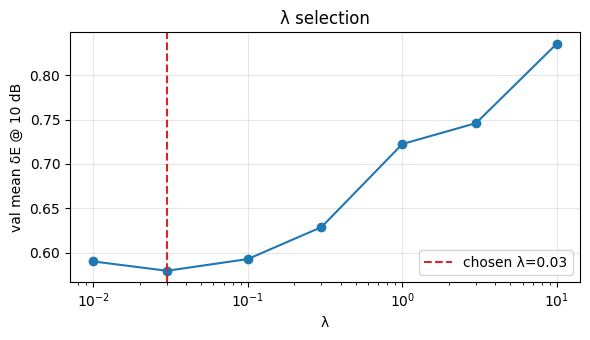

In [61]:
lambda_val_delta_e: list[float] = []

print(f"λ search: {LAMBDA_SEARCH_EPOCHS} epochs each, val δE @ {LAMBDA_VAL_SNR_DB} dB\n")
for lam in LAMBDA_CANDIDATES:
    m = new_model()
    print(f"λ = {lam:g}")
    train_model(
        m,
        train_loader,
        use_physics_loss=True,
        lam=float(lam),
        epochs=LAMBDA_SEARCH_EPOCHS,
        verbose=False,
    )
    val_de, _ = mean_delta_e_at_snr(m, val_loader, LAMBDA_VAL_SNR_DB)
    lambda_val_delta_e.append(val_de)
    print(f"  -> val δE = {val_de:.5f}\n")

best_idx = int(np.argmin(lambda_val_delta_e))
LAMBDA_OPT = float(LAMBDA_CANDIDATES[best_idx])
print(f"Selected λ = {LAMBDA_OPT:g}  (val δE = {lambda_val_delta_e[best_idx]:.5f})")

plt.figure(figsize=(6, 3.5))
plt.semilogx(LAMBDA_CANDIDATES, lambda_val_delta_e, "-o")
plt.axvline(LAMBDA_OPT, color="tab:red", ls="--", label=f"chosen λ={LAMBDA_OPT:g}")
plt.xlabel("λ")
plt.ylabel(f"val mean δE @ {LAMBDA_VAL_SNR_DB:.0f} dB")
plt.title("λ selection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Full training: run A vs. run B

Same initialization seed, same epochs and noisy training SNR range.

In [62]:
print("=== Run A: supervised only ===")
model_a = new_model()
train_model(model_a, train_loader, use_physics_loss=False, lam=0.0, epochs=EPOCHS)

print(f"\n=== Run B: supervised + physics (λ={LAMBDA_OPT:g}) ===")
model_b = new_model()
train_model(
    model_b,
    train_loader,
    use_physics_loss=True,
    lam=LAMBDA_OPT,
    epochs=EPOCHS,
)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {"model_state_dict": model_a.state_dict(), "N": N, "run": "A"},
    CKPT_A,
)
torch.save(
    {
        "model_state_dict": model_b.state_dict(),
        "N": N,
        "run": "B",
        "lambda": LAMBDA_OPT,
    },
    CKPT_B,
)
print("Saved:", CKPT_A.resolve(), CKPT_B.resolve())

=== Run A: supervised only ===
  epoch 01/15  loss=0.05280  (supervised only)
  epoch 02/15  loss=0.04008  (supervised only)
  epoch 03/15  loss=0.03993  (supervised only)
  epoch 04/15  loss=0.03895  (supervised only)
  epoch 05/15  loss=0.03754  (supervised only)
  epoch 06/15  loss=0.03570  (supervised only)
  epoch 07/15  loss=0.03424  (supervised only)
  epoch 08/15  loss=0.03348  (supervised only)
  epoch 09/15  loss=0.03295  (supervised only)
  epoch 10/15  loss=0.03242  (supervised only)
  epoch 11/15  loss=0.03217  (supervised only)
  epoch 12/15  loss=0.03187  (supervised only)
  epoch 13/15  loss=0.03157  (supervised only)
  epoch 14/15  loss=0.03128  (supervised only)
  epoch 15/15  loss=0.03108  (supervised only)

=== Run B: supervised + physics (λ=0.03) ===
  epoch 01/15  loss=0.05362  (λ=0.03)
  epoch 02/15  loss=0.04095  (λ=0.03)
  epoch 03/15  loss=0.04061  (λ=0.03)
  epoch 04/15  loss=0.03954  (λ=0.03)
  epoch 05/15  loss=0.03849  (λ=0.03)
  epoch 06/15  loss=0.03637 

## 3. Test: δE vs. trace SNR (both runs)

In [63]:
print("Run A — test sweep:")
test_de_mean_a, test_de_std_a = snr_sweep_delta_e(model_a, test_loader, SNR_SWEEP_DB)

print("\nRun B — test sweep:")
test_de_mean_b, test_de_std_b = snr_sweep_delta_e(model_b, test_loader, SNR_SWEEP_DB)

delta = test_de_mean_a - test_de_mean_b
print("\nMean δE improvement (A − B), positive => B better:")
for snr_db, d in zip(SNR_SWEEP_DB, delta):
    print(f"  @ {snr_db:5.1f} dB: {d:+.5f} rad")

Run A — test sweep:
  δE @ -10.0 dB = 0.66682 ± 0.24461
  δE @  -5.0 dB = 0.58506 ± 0.24561
  δE @   0.0 dB = 0.56137 ± 0.24855
  δE @   5.0 dB = 0.54866 ± 0.24924
  δE @  10.0 dB = 0.54711 ± 0.25080
  δE @  15.0 dB = 0.54510 ± 0.25127
  δE @  20.0 dB = 0.54507 ± 0.25133
  δE @  25.0 dB = 0.54503 ± 0.25122
  δE @  30.0 dB = 0.54496 ± 0.25118

Run B — test sweep:
  δE @ -10.0 dB = 0.64534 ± 0.23893
  δE @  -5.0 dB = 0.59174 ± 0.24345
  δE @   0.0 dB = 0.56673 ± 0.25056
  δE @   5.0 dB = 0.55670 ± 0.25137
  δE @  10.0 dB = 0.55509 ± 0.25056
  δE @  15.0 dB = 0.55453 ± 0.25087
  δE @  20.0 dB = 0.55474 ± 0.25076
  δE @  25.0 dB = 0.55455 ± 0.25074
  δE @  30.0 dB = 0.55452 ± 0.25057

Mean δE improvement (A − B), positive => B better:
  @ -10.0 dB: +0.02148 rad
  @  -5.0 dB: -0.00668 rad
  @   0.0 dB: -0.00536 rad
  @   5.0 dB: -0.00804 rad
  @  10.0 dB: -0.00798 rad
  @  15.0 dB: -0.00943 rad
  @  20.0 dB: -0.00968 rad
  @  25.0 dB: -0.00952 rad
  @  30.0 dB: -0.00956 rad


### With error bars (±1 std over test pulses)

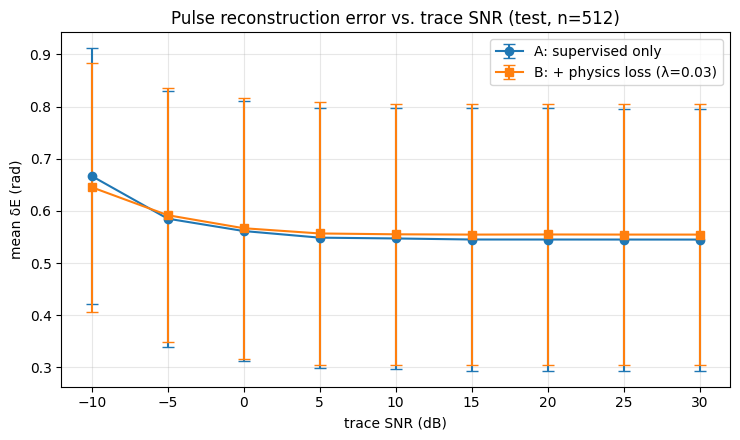

In [64]:
plt.figure(figsize=(7.5, 4.5))
plt.errorbar(
    SNR_SWEEP_DB,
    test_de_mean_a,
    yerr=test_de_std_a,
    fmt="-o",
    capsize=4,
    label="A: supervised only",
)
plt.errorbar(
    SNR_SWEEP_DB,
    test_de_mean_b,
    yerr=test_de_std_b,
    fmt="-s",
    capsize=4,
    label=f"B: + physics loss (λ={LAMBDA_OPT:g})",
)
plt.xlabel("trace SNR (dB)")
plt.ylabel("mean δE (rad)")
plt.title(f"Pulse reconstruction error vs. trace SNR (test, n={N_TEST})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Mean curves only (no error bars — easier visual comparison)

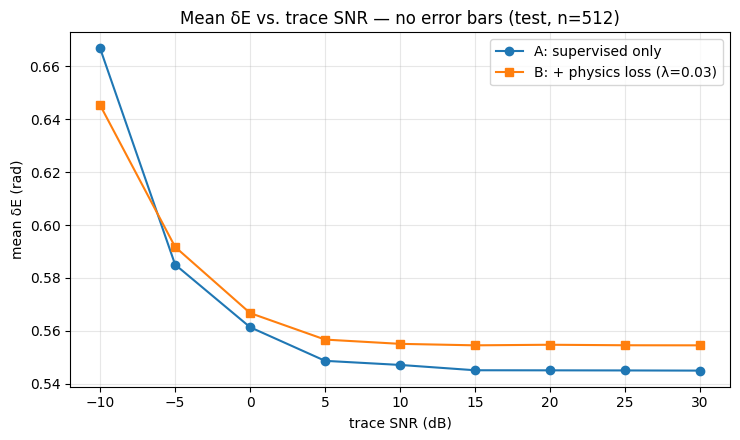

In [65]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(SNR_SWEEP_DB, test_de_mean_a, "-o", label="A: supervised only")
plt.plot(
    SNR_SWEEP_DB,
    test_de_mean_b,
    "-s",
    label=f"B: + physics loss (λ={LAMBDA_OPT:g})",
)
plt.xlabel("trace SNR (dB)")
plt.ylabel("mean δE (rad)")
plt.title(f"Mean δE vs. trace SNR — no error bars (test, n={N_TEST})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()